# 04 - Figuras y Resultados

Este notebook **genera y muestra** las figuras principales del análisis de tráfico de Punta Arenas,
usando las funciones de `src/visualization/` y los datos de `data/processed/combinaciones/`.

Las imágenes se construyen **desde cero** (no se leen de disco). Se elige **Radio** y **Steps**
al principio y se usan para todas las figuras. Los gráficos ajustan sus límites automáticamente
para mostrar **todos los datos**.

**Figuras:**
1. Pendientes (Slope) vs P95 — por índice topológico
2. Slope vs R² — búsqueda de umbral óptimo
3. Pendientes vs tiempo del día (24h)
4. Tres índices superpuestos (BC/CC/DC)
5. Comparación N505 vs N1207

In [1]:
import sys, os
# Cambiar al directorio raiz del proyecto (padre de notebooks/)
ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__) if '__file__' in dir() else os.getcwd(), '..'))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown

from functions.RutasDeArchivos import (
    Datos_computacionales,
    datos_combinaciones,
    REDES,
    RADIOS,
    STEPS,
)
from src.visualization.MedianSlopesVsPer95 import run_median_slopes_vs_per95
from src.visualization.MedianSlopesVsR2 import run_median_slopes_vs_r2
from src.visualization.ThreeSlopesVsPer95 import run_three_slopes_vs_per95
from src.visualization.Hours_vs_Slope_TrafficScale import run_hours_vs_slope


The package has been loaded successfully


## 0. Elegir configuración (Radio y Steps)

Selecciona el **Radio** y los **Steps** que se usarán en todas las figuras. Los datos
observacionales `traffic_mean_{red}_r{radio}s{steps}.csv` se cargan para ambas redes.

In [2]:
radio_sel = widgets.Dropdown(options=RADIOS, value=RADIOS[0], description='Radio:')
steps_sel = widgets.Dropdown(options=STEPS, value=STEPS[0], description='Steps:')
display(widgets.VBox([radio_sel, steps_sel]))

In [3]:
radio = radio_sel.value
steps = steps_sel.value

# Datos computacionales (centralidad topológica) por red
datos_comp = {red: pd.read_csv(Datos_computacionales[REDES.index(red)]) for red in REDES}

# Datos observacionales para la configuración elegida
datos_obs = {}
for red in REDES:
    path = datos_combinaciones[red]['mean'][(radio, steps)]
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'No existe {path}.\nElige otra combinación de Radio/Steps.'
        )
    datos_obs[red] = pd.read_csv(path)

display(Markdown(f"**Configuración:** Radio=`{radio}`, Steps=`{steps}`"))
for red in REDES:
    print(f"{red}: Obs={datos_obs[red].shape}, Comp={datos_comp[red].shape}")

**Configuración:** Radio=`0`, Steps=`3`

N505: Obs=(505, 2910), Comp=(505, 20)
N1207: Obs=(1207, 2910), Comp=(1207, 19)


## 1. Slope vs P95 (Correlación Topología-Tráfico)

**Qué se hizo:** para cada instante del día se ajusta una recta a las medianas de tráfico vs
centralidad; la pendiente (slope) mide la correlación topológica y el P95 el nivel de tráfico.
Se filtra por un umbral α y se ajusta una recta (R²). Los límites se ajustan a los datos reales.

---  **Red N505**  ---

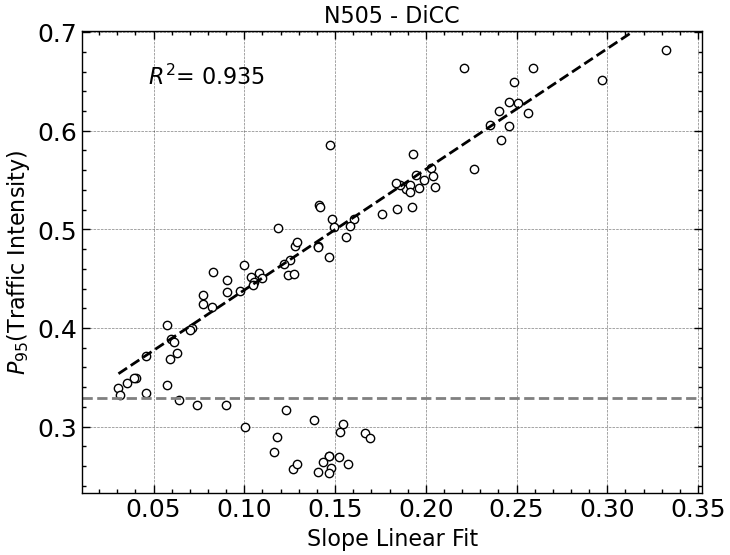

---  **Red N1207**  ---

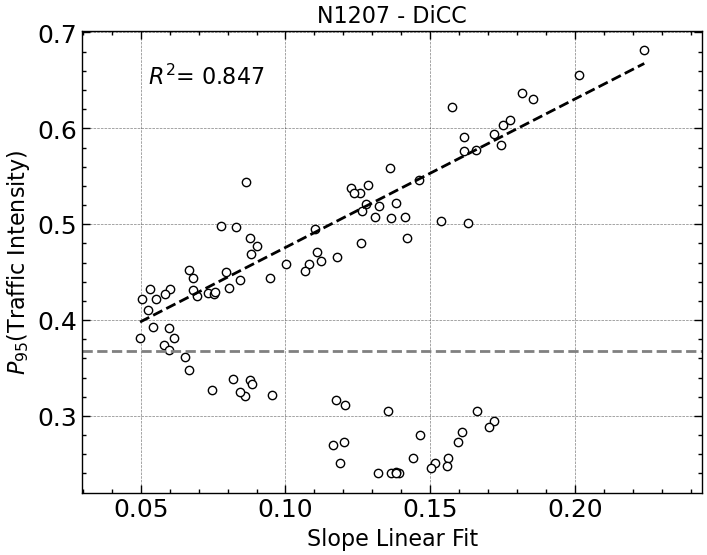

In [4]:
OPTIMAL_THRESHOLDS = {"N505": 0.329, "N1207": 0.368}
for red in REDES:
    display(Markdown(f"---  **Red {red}**  ---"))
    run_median_slopes_vs_per95(
        datos_comp=datos_comp[red],
        datos_obs=datos_obs[red],
        label=red,
        topology_index='DiCC',
        threshold=OPTIMAL_THRESHOLDS[red],
    )

## 2. Slope vs R² (Búsqueda de Umbral Óptimo)

**Qué se hizo:** se barre el umbral P95 para encontrar el que maximiza R². Los resultados
se imprimen en consola para CC y DiCC.

In [5]:
for red in REDES:
    run_median_slopes_vs_r2(
        datos_comp=datos_comp[red],
        datos_obs=datos_obs[red],
        label=red,
        topology_names=['CC', 'DiCC'],
    )


=== N505 ===
  CC: (1.433, 0.892, 0.328)
  DiCC: (1.223, 0.935, 0.328)

=== N1207 ===
  CC: (1.573, 0.776, 0.326)
  DiCC: (1.548, 0.846, 0.364)


## 3. Pendientes vs Tiempo del Día (24h)

**Qué se hizo:** se repite el ajuste de pendientes en los 96 instantes del día (cada 15 min)
para los 6 índices topológicos; la barra de la derecha codifica el P95 de tráfico.

---  **Red N505**  ---

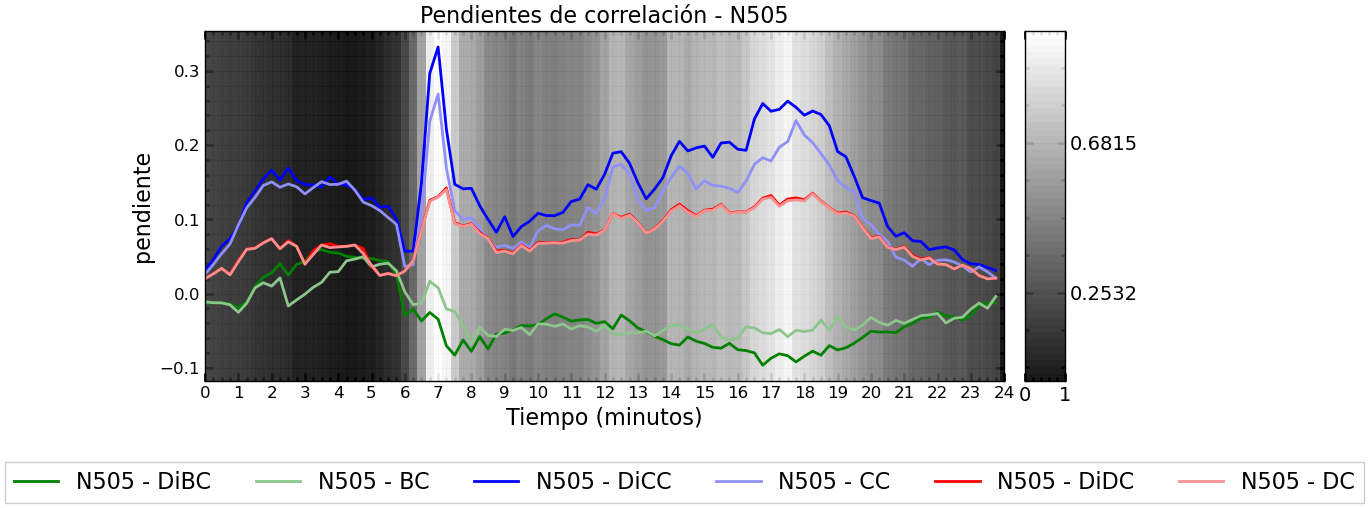

---  **Red N1207**  ---

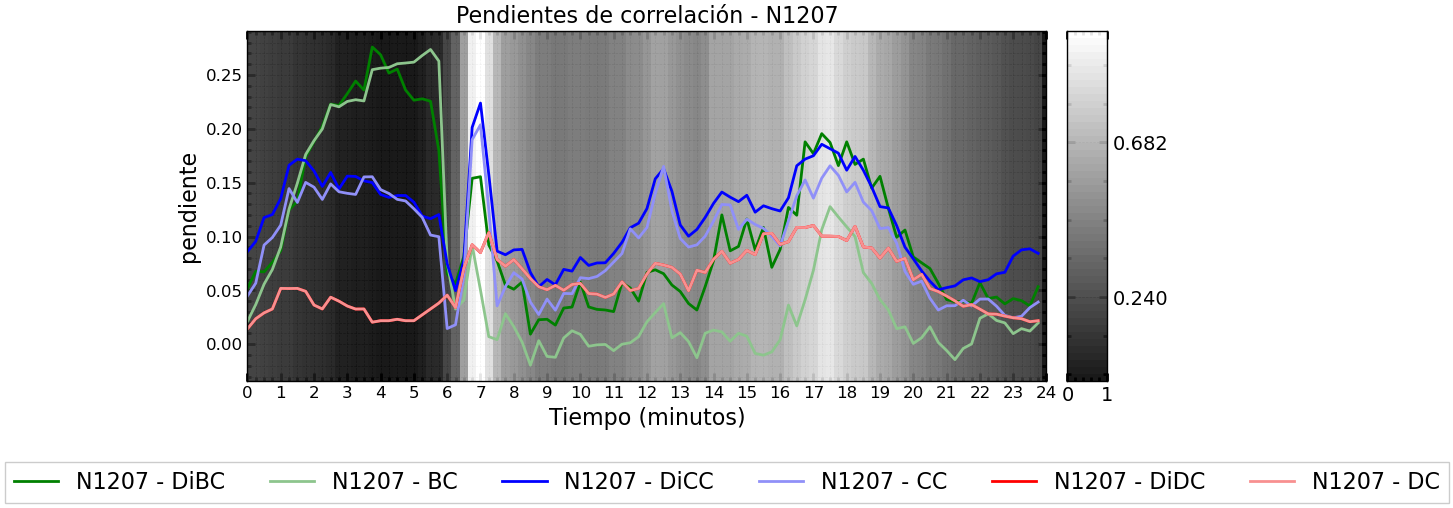

In [6]:
for red in REDES:
    display(Markdown(f"---  **Red {red}**  ---"))
    run_hours_vs_slope(
        datos_comp=datos_comp[red],
        datos_obs=datos_obs[red],
        label=red,
    )

## 4. Tres Índices Superpuestos (BC/CC/DC)

**Qué se hizo:** se superponen BC, CC y DC en un solo gráfico Slope vs P95, cada uno con su
umbral α y ajuste lineal, para comparar modelos topológicos.

---  **Red N505**  ---

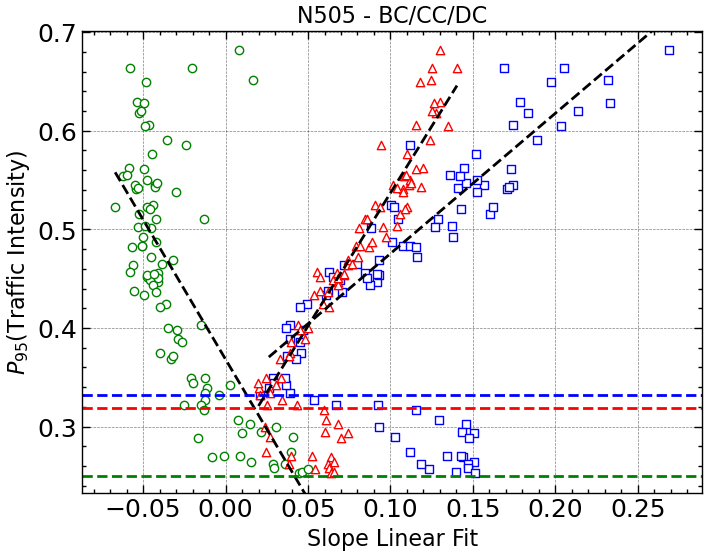

---  **Red N1207**  ---

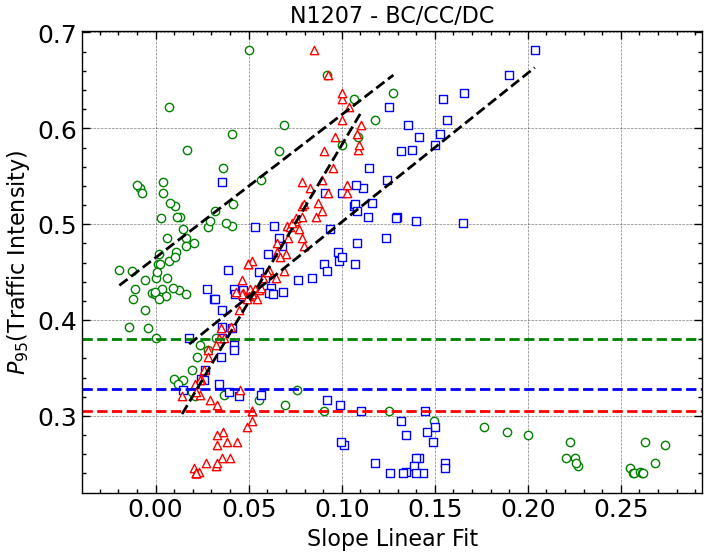

In [7]:
THREE_SLOPES_THRESHOLDS = {"N505": [0.25, 0.332, 0.319], "N1207": [0.38, 0.328, 0.305]}
for red in REDES:
    display(Markdown(f"---  **Red {red}**  ---"))
    run_three_slopes_vs_per95(
        datos_comp=datos_comp[red],
        datos_obs=datos_obs[red],
        label=red,
        topology_indices=['BC', 'CC', 'DC'],
        thresholds=THREE_SLOPES_THRESHOLDS[red],
    )

## 5. Resumen Comparativo N505 vs N1207

**Qué se hizo:** se calculan Slope vs P95 para ambas redes y se superponen los scatter plots
de los índices DiCC, DiBC y DiDC, ajustando los límites a los datos.

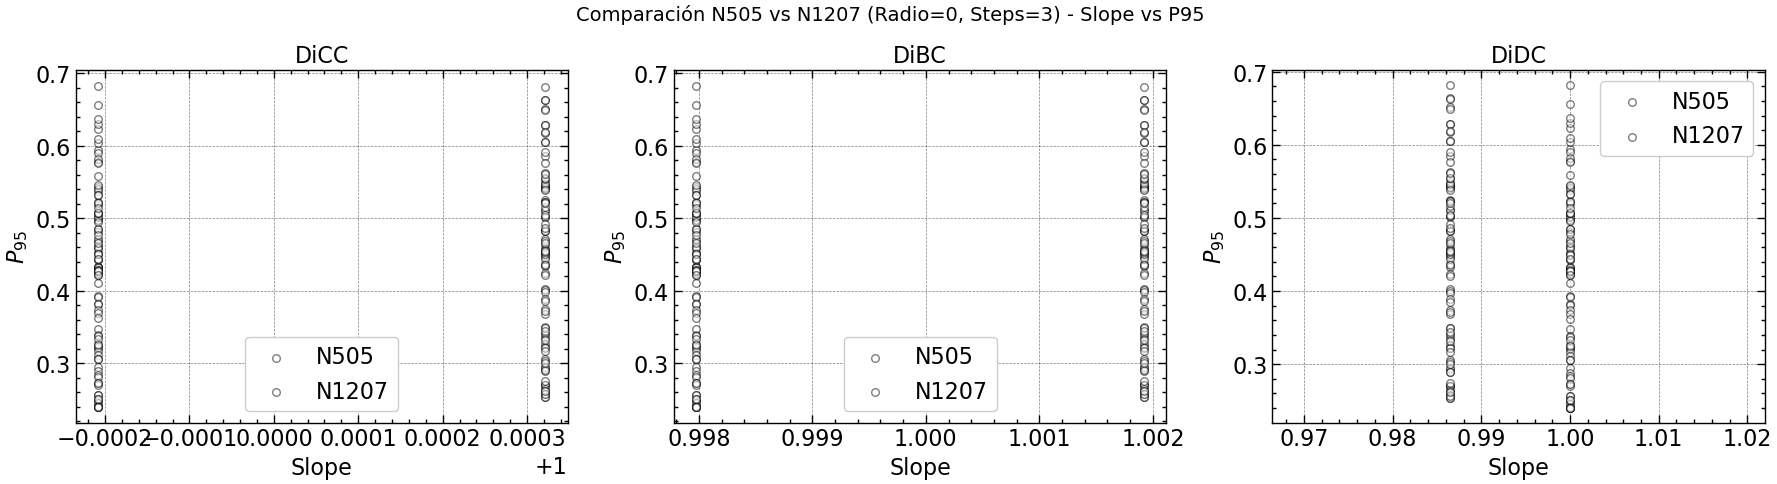

In [8]:
from functions.basics import reescalar_lista_de_listas, obtener_nombres_con_H_M_sinFDS, crearNintervalosOrdenados
import scipy

N_BOXES_MAP = {"DiBC": 15, "BC": 15, "DiCC": 20, "CC": 20, "DiDC": 3, "DC": 3}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
xs_all, ys_all = [], []
for ax, idx_name in zip(axes, ['DiCC', 'DiBC', 'DiDC']):
    for red, color in [('N505', 'blue'), ('N1207', 'red')]:
        data_comp = datos_comp[red][idx_name]
        data_comp = [(i - min(data_comp)) / (max(data_comp) - min(data_comp)) for i in data_comp]
        n_boxes = N_BOXES_MAP.get(idx_name, 20)
        Slopes, Per95 = [], []
        for hora in range(24):
            for minuto in range(0, 60, 15):
                columnas = obtener_nombres_con_H_M_sinFDS(datos_obs[red].columns, hora_exacta=(hora, minuto))
                if not columnas:
                    continue
                data_obs_iter = datos_obs[red][columnas].values.tolist()
                data_obs_iter = reescalar_lista_de_listas(data_obs_iter, 255)
                promedios = [np.mean(data) for data in data_obs_iter]
                p95 = np.percentile(promedios, 95)
                y_med, x_med = crearNintervalosOrdenados(data_comp, promedios, n_boxes)
                y_m = [np.median(sub) for sub in y_med if sub]
                x_m = [np.mean(sub) for sub in y_med if sub]
                if len(x_m) >= 2:
                    Slopes.append(scipy.stats.linregress(x_m, y_m).slope)
                    Per95.append(p95)
        xs_all.extend(Slopes); ys_all.extend(Per95)
        ax.scatter(Slopes, Per95, alpha=0.5, label=red, color=color, edgecolors='black', facecolors='white', s=30)
    ax.set_xlabel('Slope'); ax.set_ylabel(r'$P_{95}$'); ax.set_title(idx_name); ax.legend()

if xs_all:
    plt.xlim(min(xs_all) - 0.02, max(xs_all) + 0.02)
    plt.ylim(min(ys_all) - 0.02, max(ys_all) + 0.02)
plt.suptitle(f'Comparación N505 vs N1207 (Radio={radio}, Steps={steps}) - Slope vs P95', fontsize=14)
plt.tight_layout()
plt.show()